# MoodNote-AI — Fine-tune PhoBERT-v2 trên Google Colab

Pipeline phân loại cảm xúc tiếng Việt (7 classes) với **PhoBERT-v2** + UIT-VSMEC + ViGoEmotions.

## Workflow

**Local (máy bạn):**
```bash
python scripts/prepare_data.py --hf-token hf_xxx
```
Sau đó upload thư mục `data/processed/` lên Drive tại `MyDrive/MoodNote-AI/processed/`.

**Colab (notebook này):**

| Cell | Mô tả |
|------|-------|
| 1    | GPU check, Mount Drive, Clone repo, Cài dependencies |
| 2    | Copy processed data từ Drive → Colab local |
| 2b   | **Back-translation augmentation** (Enjoyment/Anger/Surprise) — chạy 1 lần, kết quả lưu Drive |
| 3    | Train PhoBERT-v2, lưu checkpoint về Drive |
| 4    | Evaluate + test predict |

> **Trước khi chạy:** Runtime → Change runtime type → **T4 GPU**
>
> **Cell 2b** chỉ cần chạy 1 lần. Lần sau nếu Drive đã có `train_augmented.csv` với BT thì skip cell này.

> **Kiến trúc model:** mean pooling theo `attention_mask` + head 2 tầng, không dùng CLS-only.

In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────

# GPU check
import torch
if not torch.cuda.is_available():
    raise RuntimeError("GPU not found. Runtime -> Change runtime type -> T4 GPU")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Clone / pull repo
import os, subprocess, sys

REPO_URL = 'https://github.com/ToanHuynh0201/MoodNote-AI.git'
REPO_DIR = '/content/MoodNote-AI'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', '-C', REPO_DIR, 'pull', '--rebase'], check=True)

os.chdir(REPO_DIR)
subprocess.run(['pip', 'install', '-r', 'requirements.txt', '-q'], check=True)
sys.path.insert(0, REPO_DIR)

# Paths
CONFIG_DIR     = f'{REPO_DIR}/configs'
PROCESSED_DIR  = f'{REPO_DIR}/data/processed'
DRIVE_DIR      = '/content/drive/MyDrive/MoodNote-AI'
CHECKPOINT_DIR = '/content/checkpoints'   # local Colab — tự xóa khi session kết thúc
BEST_MODEL_DIR = f'{DRIVE_DIR}/best_model'  # chỉ best model mới lên Drive

for d in [PROCESSED_DIR, CHECKPOINT_DIR, BEST_MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

print("\nSetup hoàn tất.")
print(f"  Repo        : {REPO_DIR}")
print(f"  Checkpoints : {CHECKPOINT_DIR}  (local, không tốn Drive)")
print(f"  Best model  : {BEST_MODEL_DIR}  (Drive)")

GPU: Tesla T4
VRAM: 15.6 GB
Mounted at /content/drive

Setup hoàn tất.
  Repo        : /content/MoodNote-AI
  Checkpoints : /content/checkpoints  (local, không tốn Drive)
  Best model  : /content/drive/MyDrive/MoodNote-AI/best_model  (Drive)


In [2]:
# ── Cell 2: Copy processed data từ Drive ──────────────────────────────────────
# Yêu cầu: đã upload data/processed/ lên Drive tại MyDrive/MoodNote-AI/processed/
# (chạy `python scripts/prepare_data.py` trên máy local trước)

import os, shutil

DRIVE_PROCESSED = f'{DRIVE_DIR}/processed'

if not os.path.exists(DRIVE_PROCESSED):
    raise FileNotFoundError(
        f"Không tìm thấy {DRIVE_PROCESSED}\n"
        "Hãy upload thư mục data/processed/ từ máy local lên "
        "Google Drive tại MyDrive/MoodNote-AI/processed/"
    )

required = ['train.csv', 'train_augmented.csv', 'validation.csv', 'test.csv']
missing  = [f for f in required if not os.path.exists(f'{DRIVE_PROCESSED}/{f}')]
if missing:
    print(f"Warning: thiếu files: {missing}")
    print("Tiếp tục với các files hiện có...")

# Copy từ Drive vào Colab local
for fname in required:
    src = f'{DRIVE_PROCESSED}/{fname}'
    dst = f'{PROCESSED_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1024**2
        print(f"  Copied {fname} ({size_mb:.1f} MB)")
    else:
        print(f"  Skipped {fname} (not found in Drive)")

# Quick sanity check
import pandas as pd
for split in ['train', 'validation', 'test']:
    path = f'{PROCESSED_DIR}/{split}.csv'
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"  {split:12s}: {len(df):5d} samples, cols={list(df.columns)}")

aug_path = f'{PROCESSED_DIR}/train_augmented.csv'
if os.path.exists(aug_path):
    df_aug = pd.read_csv(aug_path)
    print(f"  {'train_aug':12s}: {len(df_aug):5d} samples")

print("\nData ready.")

  Copied train.csv (0.5 MB)
  Copied train_augmented.csv (0.8 MB)
  Copied validation.csv (0.1 MB)
  Copied test.csv (0.1 MB)
  train       :  6677 samples, cols=['text', 'label']
  validation  :   828 samples, cols=['text', 'label']
  test        :   693 samples, cols=['text', 'label']
  train_aug   : 10082 samples

Data ready.


In [3]:
# ── Cell 2b: Back-translation augmentation (chạy trên Colab trước khi train) ───
# Ghi đè train_augmented.csv với back-translation cho Enjoyment/Anger/Surprise.
# Bỏ qua cell này nếu muốn dùng train_augmented.csv đã upload từ local.

import os, subprocess
os.chdir(REPO_DIR)

subprocess.run(['pip', 'install', 'deep_translator', '-q'], check=True)
subprocess.run(['python', 'scripts/augment_colab.py'], check=True)

# Copy kết quả lên Drive để tái sử dụng
import shutil
shutil.copy2(
    f'{PROCESSED_DIR}/train_augmented.csv',
    f'{DRIVE_DIR}/processed/train_augmented.csv',
)
print("train_augmented.csv (with back-translation) saved to Drive.")

train_augmented.csv (with back-translation) saved to Drive.


INFO - Logger initialized. Log file: logs/model_utils_20260403_010228.log


INFO:model_utils:Logger initialized. Log file: logs/model_utils_20260403_010228.log


[INFO] Running in WANDB offline mode
INFO - Logger initialized. Log file: logs/moodnote_20260403_010235.log


INFO:moodnote:Logger initialized. Log file: logs/moodnote_20260403_010235.log


INFO - Logger initialized. Log file: logs/moodnote_20260403_010235.log


...

INFO -   epoch: 5.3803


INFO:moodnote:  epoch: 5.3803



Evaluation Metrics

Overall Metrics:
  Accuracy:    0.6580
  F1-Macro:    0.6062
  F1-Weighted: 0.6538

Per-Class Metrics:
Emotion         Precision    Recall       F1-Score     Support   
------------------------------------------------------------
Enjoyment       0.7684       0.7565       0.7624       193       
Sadness         0.6923       0.6983       0.6953       116       
Anger           0.5714       0.3000       0.3934       40        
Fear            0.6800       0.7391       0.7083       46        
Disgust         0.6143       0.6515       0.6324       132       
Surprise        0.5833       0.3784       0.4590       37        
Other           0.5497       0.6434       0.5929       129       

Confusion matrix saved to /content/checkpoints/confusion_matrix.png
INFO - Model saved to /content/drive/MyDrive/MoodNote-AI/best_model


INFO:model_utils:Model saved to /content/drive/MyDrive/MoodNote-AI/best_model



TRAINING HOÀN TẤT
Accuracy   : 0.6580
F1-Macro   : 0.6062
F1-Weighted: 0.6538
Model saved: /content/drive/MyDrive/MoodNote-AI/best_model


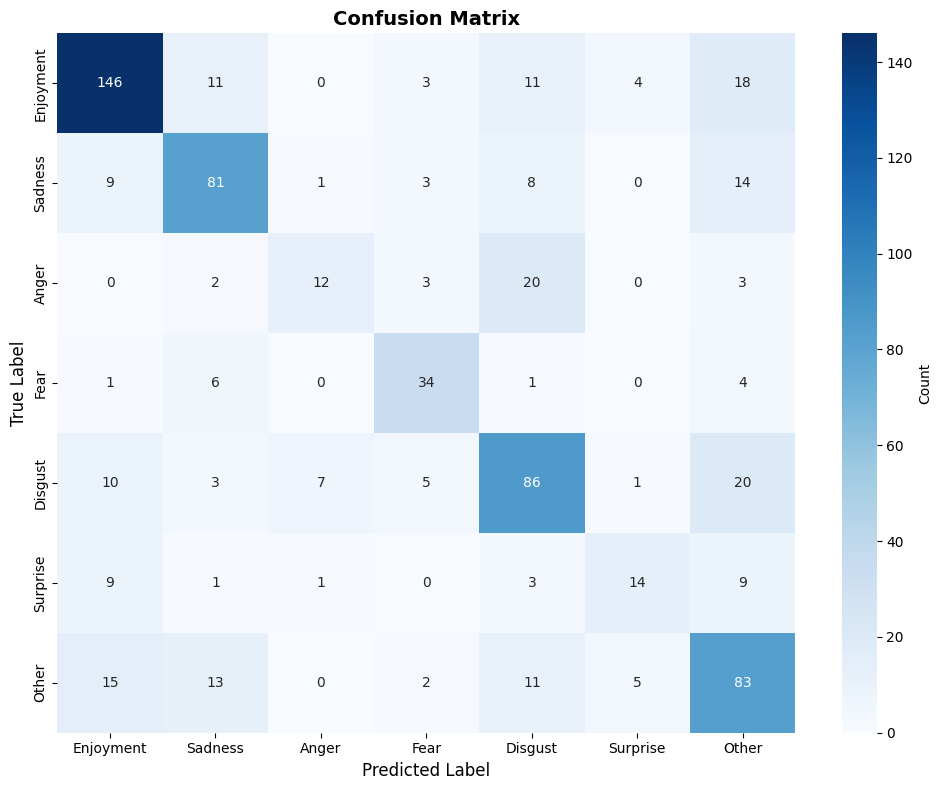

In [ ]:
# ── Cell 3: Train ─────────────────────────────────────────────────────────────
import os, torch
os.environ["WANDB_MODE"] = "offline"  # skip interactive prompt
import pandas as pd
import numpy as np
from pathlib import Path
os.chdir(REPO_DIR)

from src.data.dataset import EmotionDataset
from src.models.phobert_classifier import PhoBERTEmotionClassifier
from src.models.model_utils import save_model, get_device, print_model_summary
from src.training.trainer import train_model
from src.utils.config import load_all_configs
from src.utils.logger import setup_logger
from src.utils.metrics import compute_metrics, print_metrics, plot_confusion_matrix

logger = setup_logger(name='moodnote')

configs         = load_all_configs(CONFIG_DIR)
model_config    = configs['model']
training_config = configs['training']

logger.info(f"Model      : {model_config['model']['name']}")
logger.info(f"Batch size : {training_config['training']['batch_size']}")
logger.info(f"LR         : {training_config['training']['learning_rate']}")

device     = get_device()
model_name = model_config['model']['name']
max_len    = model_config['model']['max_seq_length']

# Smoke test
from transformers import AutoModel as _AM
_m = _AM.from_pretrained(model_name)
assert _m.config.hidden_size == 768
assert _m.config.num_hidden_layers == 12
del _m
logger.info("Smoke test passed: hidden_size=768, num_hidden_layers=12")

# Dùng train_augmented nếu có, fallback về train.csv
aug_path    = f'{PROCESSED_DIR}/train_augmented.csv'
TRAIN_CSV   = aug_path if os.path.exists(aug_path) else f'{PROCESSED_DIR}/train.csv'
logger.info(f"Train file : {TRAIN_CSV}")

train_dataset = EmotionDataset(TRAIN_CSV,                             tokenizer_name=model_name, max_length=max_len)
val_dataset   = EmotionDataset(f'{PROCESSED_DIR}/validation.csv',    tokenizer_name=model_name, max_length=max_len)
test_dataset  = EmotionDataset(f'{PROCESSED_DIR}/test.csv',          tokenizer_name=model_name, max_length=max_len)

logger.info(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Class weights
train_labels  = pd.read_csv(TRAIN_CSV)['label'].tolist()
class_counts  = np.bincount(train_labels, minlength=7).astype(float)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 7
print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  {model_config['emotion_labels'][i]:<12}: {w:.3f}")

# Model
model = PhoBERTEmotionClassifier(
    model_name=model_name,
    num_labels=model_config['model']['num_labels'],
    dropout=model_config['model']['dropout'],
    class_weights=class_weights,
    label_smoothing=model_config['model'].get('label_smoothing', 0.0),
    focal_gamma=model_config['model'].get('focal_gamma', 2.0),
)
model.to(device)
print_model_summary(model)

# Train
print("\n" + "=" * 50)
print("Training PhoBERT-v2 — processed VSMEC + ViGoEmotions + augmentation")
print("=" * 50)

trainer = train_model(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    training_config=training_config,
    output_dir=CHECKPOINT_DIR,
    use_wandb=training_config.get('wandb', {}).get('enabled', False),
)

# Evaluate on test set
predictions = trainer.predict(test_dataset)
detailed    = compute_metrics(predictions.predictions, predictions.label_ids)
print_metrics(detailed, model_config['emotion_labels'])

plot_confusion_matrix(
    predictions.predictions, predictions.label_ids,
    emotion_labels=model_config['emotion_labels'],
    save_path=Path(CHECKPOINT_DIR) / 'confusion_matrix.png',
)

# Save best model to Drive
save_model(
    model=trainer.model,
    tokenizer=train_dataset.tokenizer,
    save_dir=BEST_MODEL_DIR,
    config={
        'model_config':    model_config,
        'training_config': training_config,
        'test_results': {
            'accuracy':    detailed['accuracy'],
            'f1_macro':    detailed['f1_macro'],
            'f1_weighted': detailed['f1_weighted'],
        },
    },
)

print("\n" + "=" * 50)
print("TRAINING HOÀN TẤT")
print("=" * 50)
print(f"Accuracy   : {detailed['accuracy']:.4f}")
print(f"F1-Macro   : {detailed['f1_macro']:.4f}")
print(f"F1-Weighted: {detailed['f1_weighted']:.4f}")
print(f"Model saved: {BEST_MODEL_DIR}")

In [5]:
# ── Cell 4: Evaluate & Test predict ───────────────────────────────────────────
import os
os.chdir(REPO_DIR)

from src.inference.predictor import EmotionPredictor
from src.data.preprocess import VietnamesePreprocessor

print("Files trong best_model:")
for f in sorted(os.listdir(BEST_MODEL_DIR)):
    size = os.path.getsize(f'{BEST_MODEL_DIR}/{f}') / 1024**2
    print(f"  {f:<30} {size:.1f} MB")

# ── Debug: kiểm tra pyvi segmentation ──────────────────────────────────────────
print("\n" + "=" * 60)
print("DEBUG: pyvi segmentation")
print("=" * 60)

preprocessor = VietnamesePreprocessor(segmenter='pyvi')
test_sentences = [
    "Hôm nay tôi rất vui vì được nghỉ học!",
    "Tôi buồn quá, không biết phải làm sao.",
    "Thật tức giận khi bị đối xử bất công.",
    "Trời ơi, tin này làm tôi bất ngờ quá!",
    "Tôi sợ lắm, không dám đi một mình.",
    "Thấy ghê quá, không thể chịu được.",
]

for sentence in test_sentences:
    segmented = preprocessor.segment_text(sentence)
    print(f"  Raw      : {sentence}")
    print(f"  Segmented: {segmented}")
    print()

# ── Predict ─────────────────────────────────────────────────────────────────────
print("=" * 60)
print("Test predict")
print("=" * 60)

predictor = EmotionPredictor(model_path=BEST_MODEL_DIR)

for sentence in test_sentences:
    result = predictor.predict(sentence)
    segmented = preprocessor.segment_text(sentence)
    print(f"  Raw       : {sentence}")
    print(f"  Segmented : {segmented}")
    print(f"  Emotion   : {result['emotion']}  (confidence: {result['confidence']:.2%})")
    top3 = sorted(result['probabilities'].items(), key=lambda x: x[1], reverse=True)[:3]
    print(f"  Top-3     : {', '.join(f'{e}={p:.2%}' for e, p in top3)}")
    print()

INFO - Logger initialized. Log file: logs/predictor_20260403_012842.log


INFO:predictor:Logger initialized. Log file: logs/predictor_20260403_012842.log


Files trong best_model:
  added_tokens.json              0.0 MB
  bpe.codes                      1.1 MB
  config.yaml                    0.0 MB
  model.pt                       513.9 MB
  tokenizer_config.json          0.0 MB
  vocab.txt                      0.9 MB

DEBUG: pyvi segmentation
  Raw      : Hôm nay tôi rất vui vì được nghỉ học!
  Segmented: Hôm_nay tôi rất vui vì được nghỉ học !

  Raw      : Tôi buồn quá, không biết phải làm sao.
  Segmented: Tôi buồn quá , không biết phải làm_sao .

  Raw      : Thật tức giận khi bị đối xử bất công.
  Segmented: Thật tức_giận khi bị đối_xử bất_công .

  Raw      : Trời ơi, tin này làm tôi bất ngờ quá!
  Segmented: Trời_ơi , tin này làm tôi bất_ngờ quá !

  Raw      : Tôi sợ lắm, không dám đi một mình.
  Segmented: Tôi sợ lắm , không dám đi một_mình .

  Raw      : Thấy ghê quá, không thể chịu được.
  Segmented: Thấy ghê quá , không_thể chịu được .

Test predict
INFO - Loading model from /content/drive/MyDrive/MoodNote-AI/best_model...


INFO:predictor:Loading model from /content/drive/MyDrive/MoodNote-AI/best_model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO - Model loaded from /content/drive/MyDrive/MoodNote-AI/best_model


INFO:model_utils:Model loaded from /content/drive/MyDrive/MoodNote-AI/best_model


INFO - Predictor initialized successfully!


INFO:predictor:Predictor initialized successfully!


  Raw       : Hôm nay tôi rất vui vì được nghỉ học!
  Segmented : Hôm_nay tôi rất vui vì được nghỉ học !
  Emotion   : Enjoyment  (confidence: 83.43%)
  Top-3     : Enjoyment=83.43%, Surprise=6.02%, Disgust=4.86%

  Raw       : Tôi buồn quá, không biết phải làm sao.
  Segmented : Tôi buồn quá , không biết phải làm_sao .
  Emotion   : Sadness  (confidence: 95.68%)
  Top-3     : Sadness=95.68%, Anger=1.76%, Fear=1.13%

  Raw       : Thật tức giận khi bị đối xử bất công.
  Segmented : Thật tức_giận khi bị đối_xử bất_công .
  Emotion   : Anger  (confidence: 85.86%)
  Top-3     : Anger=85.86%, Disgust=6.33%, Sadness=4.12%

  Raw       : Trời ơi, tin này làm tôi bất ngờ quá!
  Segmented : Trời_ơi , tin này làm tôi bất_ngờ quá !
  Emotion   : Surprise  (confidence: 69.71%)
  Top-3     : Surprise=69.71%, Fear=25.28%, Sadness=1.81%

  Raw       : Tôi sợ lắm, không dám đi một mình.
  Segmented : Tôi sợ lắm , không dám đi một_mình .
  Emotion   : Fear  (confidence: 99.47%)
  Top-3     : Fear=99.4